In [203]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [204]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [205]:
data = pd.read_csv('../algo_impliment_real_data_set/Batch_gradient_descent/insurance.csv')

In [206]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [207]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [208]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [209]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


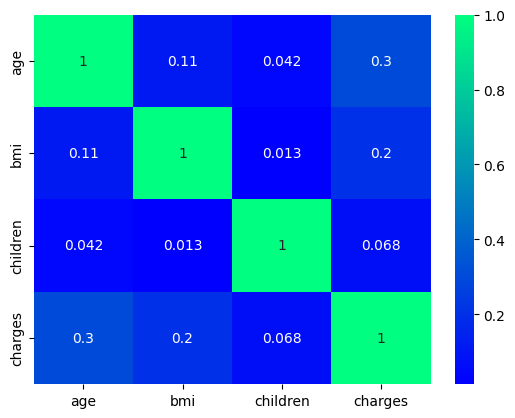

In [210]:
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='winter')
plt.show()

In [211]:
data['sex'] = data['sex'].map({"female":0,"male":1})
data['smoker'] = data['smoker'].map({"yes":1,"no":0})

## One-Hot Encoding

In [212]:
df = pd.get_dummies(data,drop_first=True,dtype=int) 

In [213]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [214]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [215]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,1
1,18,1,33.770,1,0,0,1,0
2,28,1,33.000,3,0,0,1,0
3,33,1,22.705,0,0,1,0,0
4,32,1,28.880,0,0,1,0,0


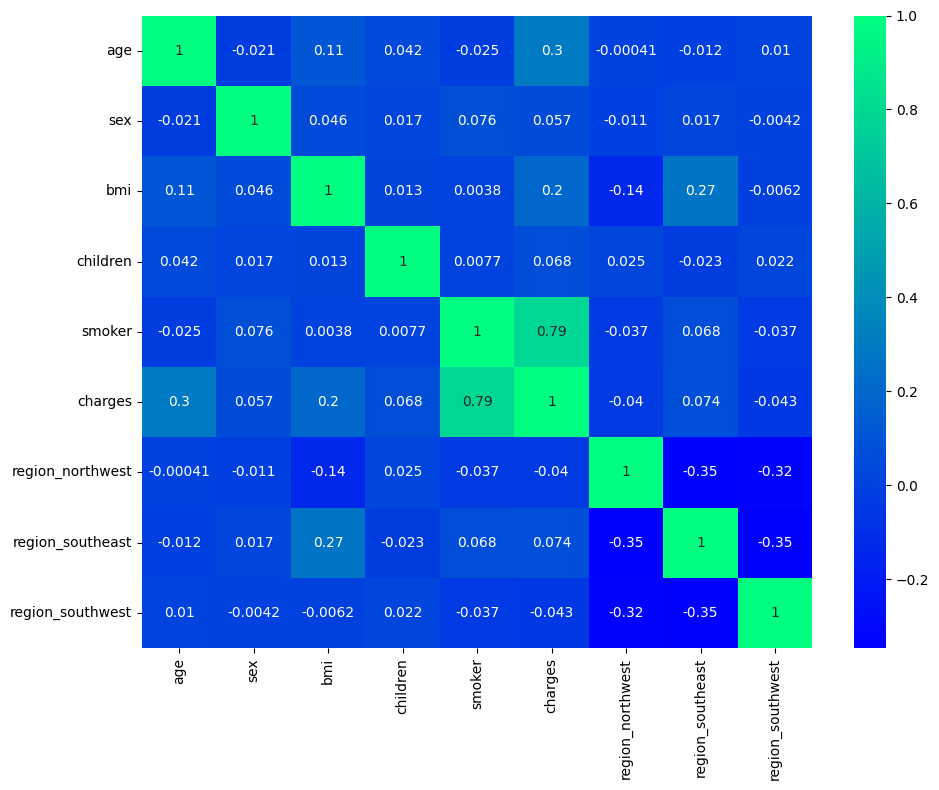

In [216]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),cmap='winter',annot=True)
plt.tight_layout()
plt.show()

## Linear Regression

In [217]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [218]:
model = LinearRegression()

In [219]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [220]:
y_pred = model.predict(X_test)

In [221]:
r2 = r2_score(y_test,y_pred)
print(f"r2 score: {r2}")
ad_r2 = 1 - ((1 - r2) * (X_train.shape[0] - 1) / (X_train.shape[0] - 1 - X_train.shape[1]))
print(f"adjusted r2 score : {ad_r2}")

r2 score: 0.7835929767120724
adjusted r2 score : 0.7819612555185724


## polynomial Regression

In [252]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly,y_train)

print("r2 : ",model.score(X_test_poly,y_test))

r2 :  0.8665830903164852


## muticolinearity detection 

In [223]:
X_train.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
560,46,0,19.95,2,0,1,0,0
1285,47,0,24.32,0,0,0,0,0
1142,52,0,24.86,0,0,0,1,0
969,39,0,34.32,5,0,0,1,0
486,54,0,21.47,3,0,1,0,0


In [224]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["feature"] = X_train.columns
vif["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X.shape[1])]
vif

,feature,VIF
0,age,7.848186
1,sex,2.015454
2,bmi,11.226908
3,children,1.812358
4,smoker,1.259327
5,region_northwest,1.876922
6,region_southeast,2.189733
7,region_southwest,1.965852


In [225]:
df.corr()["charges"].sort_values(ascending=False)

charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64

## applying feature selection 

## VarianceThreshold

In [226]:
X_train.var()

age                 198.076354
sex                   0.250086
bmi                  36.522510
children              1.478616
smoker                0.163486
region_northwest      0.182181
region_southeast      0.194715
region_southwest      0.186028
dtype: float64

In [227]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Variance Threshold
vt = VarianceThreshold(threshold=0.01)

X_train_vt = vt.fit_transform(X_train_scaled)
X_test_vt = vt.transform(X_test_scaled)

print(vt.get_support())

[ True  True  True  True  True  True  True  True]


## ANOVA

In [228]:
from sklearn.feature_selection import SelectKBest, f_regression

anova = SelectKBest(score_func=f_regression, k=5)

X_train_anova = anova.fit_transform(X_train_scaled, y_train)
X_test_anova = anova.transform(X_test_scaled)

print(anova.scores_)

[9.20709050e+01 3.45707513e+00 4.32657103e+01 5.54750260e+00
 1.65995210e+03 1.21978344e+00 4.88708675e+00 1.30946335e+00]


In [229]:
new_df = pd.DataFrame(X_train_anova,columns=anova.get_feature_names_out())

In [230]:
new_df.head()

,x0,x2,x3,x4,x6
0,0.472227,-1.756525,0.734336,-0.508747,-0.599661
1,0.543313,-1.033082,-0.911192,-0.508747,-0.599661
2,0.898745,-0.943687,-0.911192,-0.508747,1.667609
3,-0.025379,0.622393,3.202629,-0.508747,1.667609
4,1.040918,-1.504893,1.557100,-0.508747,-0.599661


In [231]:
model = LinearRegression()
model.fit(X_train_anova, y_train)
pred = model.predict(X_test_anova)
print("Anova r2 : ",r2_score(y_test,pred))

Anova r2 :  0.7821545605295674


## RFE

In [232]:
from sklearn.feature_selection import RFE

model = LinearRegression()
rfe = RFE(model, n_features_to_select=5)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)
print(rfe.support_)

[ True False  True  True  True False False  True]


In [233]:
new_df = pd.DataFrame(X_train_rfe,columns=rfe.get_feature_names_out())

In [234]:
new_df.head()

,x0,x2,x3,x4,x7
0,0.472227,-1.756525,0.734336,-0.508747,-0.572314
1,0.543313,-1.033082,-0.911192,-0.508747,-0.572314
2,0.898745,-0.943687,-0.911192,-0.508747,-0.572314
3,-0.025379,0.622393,3.202629,-0.508747,-0.572314
4,1.040918,-1.504893,1.557100,-0.508747,-0.572314


In [235]:
## appling linearRegression

In [236]:
model = LinearRegression()
model.fit(X_train_rfe, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [237]:
pred = model.predict(X_test_rfe)

In [238]:
print("RFE : ",r2_score(y_test,pred))

RFE :  0.7814260513320903


In [244]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

model = LinearRegression()
model.fit(X_train_poly,y_train)

print("r2 : ",model.score(X_test_poly,y_test))

r2 :  0.866583090316484
